# Razors Edge Real Cpu Contours

Shows the Razor's Edge contours for `RazorsEdgeCPUBenchmarkTask`.


In [1]:
from pathlib import Path
import sys
import psutil
import os

repo_root = Path.cwd()

while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(repo_root / "src"))

p = psutil.Process(os.getpid())
if psutil.WINDOWS:
    p.nice(psutil.HIGH_PRIORITY_CLASS)
else:
    try:
        p.nice(-10)
    except psutil.AccessDenied:
        print("Elevation (sudo) is required to set high priority on Unix.")

In [2]:
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import numpy as np

from demos.cpu.razors_edge_cpu_benchmark_task import RazorsEdgeCPUBenchmarkTask
from razors_edge.optimal_batching import _compiled_dynamic_batcher

In [3]:
initialized_task = RazorsEdgeCPUBenchmarkTask(ThreadPoolExecutor(1))
batch_sizes = range(2, initialized_task.batch_benchmark_sizes[-1]+1)
num_batches = len(batch_sizes)

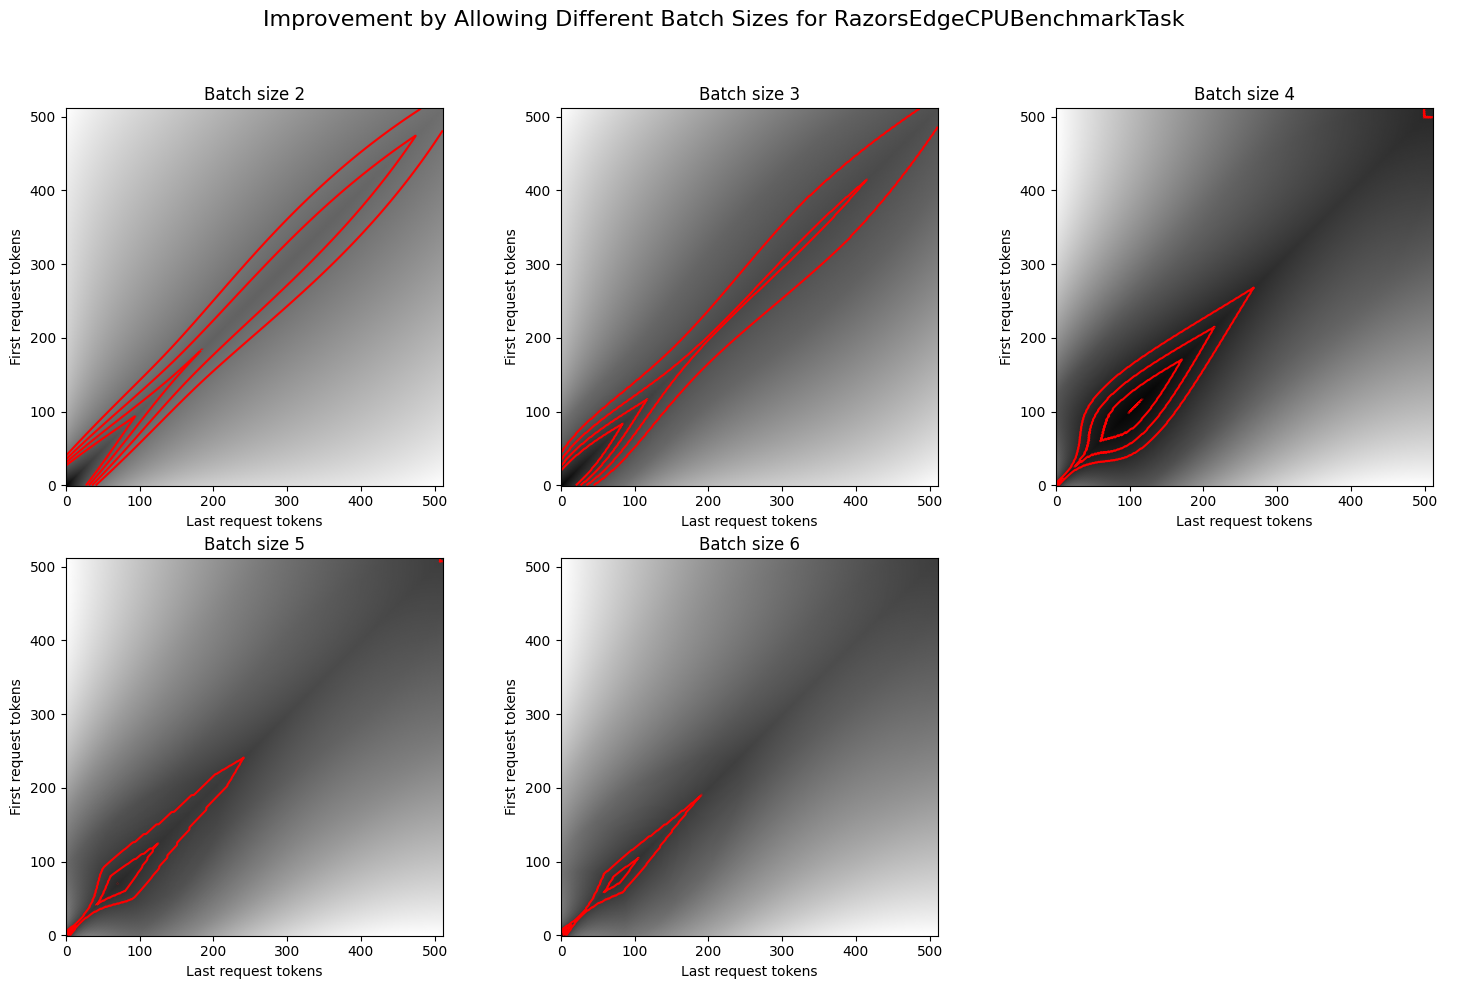

In [4]:
cols = 3
rows = int(np.ceil(num_batches / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten()  # Flatten to simplify indexing

input_size = initialized_task.max_input_size

for idx, allowed_batch_size in enumerate(batch_sizes):
    image = np.zeros((input_size, input_size), dtype=np.float32)
    for i in range(input_size):
        for j in range(i+1):
            tokens = np.linspace(j, i, allowed_batch_size).astype(np.uint32)
            time_ratio = initialized_task.batch_timing_estimators[allowed_batch_size-1, i] / _compiled_dynamic_batcher(tokens, initialized_task.batch_timing_estimators[:allowed_batch_size-1])[0][-1]
            image[i, j] = time_ratio
            image[j, i] = time_ratio

    ax = axes[idx]
    ax.set_title(f"Batch size {allowed_batch_size}")
    ax.set_ylabel("First request tokens")
    ax.set_xlabel("Last request tokens")
    im = ax.imshow(image, origin='lower', cmap='gray')
    ax.contour(image, levels=[0.85, 0.9, 0.95, 1], colors='red')

# Turn off any unused subplots
for ax in axes[num_batches:]:
    ax.axis('off')

fig.suptitle("Improvement by Allowing Different Batch Sizes for RazorsEdgeCPUBenchmarkTask", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the suptitle
fig.savefig(Path("..") / ".." / "images" / f"{fig.get_suptitle()}.png")
plt.show()